In [3]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

def load_and_filter(cfg):
    """
    根据配置加载并过滤CSV，返回统一列名的DataFrame (qps, recall, mrr)
    mrr 列若不存在则填充 NaN，不会报错。
    cfg: dict, 包含:
        'path': CSV路径
        'topk': int or None, 若指定且列存在则过滤
        'filters': dict or None, 键为列名，值为列表（保留这些值）
    """
    df = pd.read_csv(cfg['path'])

    # 1) 过滤 topk（如果指定）
    if cfg.get('topk') is not None:
        for col in ['topk', 'K', 'k']:
            if col in df.columns:
                df = df[df[col] == cfg['topk']]
                break

    # 2) 应用多个过滤条件
    filters = cfg.get('filters', {})
    for col, vals in filters.items():
        if col not in df.columns:
            warnings.warn(f"列 '{col}' 不存在于 {cfg['path']}，跳过该过滤")
            continue
        if not isinstance(vals, (list, tuple)):
            vals = [vals]
        df = df[df[col].isin(vals)]

    if df.empty:
        raise ValueError(f"过滤后无数据: {cfg['path']}")

    # 3) 映射列名到统一名称
    qps_col = None
    for c in ['qps', 'QPS']:
        if c in df.columns:
            qps_col = c
            break
    if qps_col is None:
        raise ValueError(f"未找到 QPS 列，现有列: {df.columns}")

    recall_col = None
    for c in ['recall@100', 'recall_100', 'Recall@100', 'recall']:
        if c in df.columns:
            recall_col = c
            break
    if recall_col is None:
        raise ValueError(f"未找到 Recall 列，现有列: {df.columns}")

    # --- mrr 列为可选 ---
    mrr_col = None
    for c in ['mrr@100', 'mrr_100', 'MRR@100', 'mrr']:
        if c in df.columns:
            mrr_col = c
            break

    # 提取 qps 和 recall
    df_out = df[[qps_col, recall_col]].rename(
        columns={qps_col: 'qps', recall_col: 'recall'}
    )

    # 添加 mrr 列（若存在则取，否则填充 NaN）
    if mrr_col is not None:
        df_out['mrr'] = df[mrr_col]
    else:
        warnings.warn(f"未找到 MRR 列，将填充 NaN (仅绘制 Recall 曲线)")
        df_out['mrr'] = float('nan')

    # 按QPS排序
    df_out = df_out.sort_values('qps')
    return df_out


def plot_all_methods(csv_configs, suptitle=None, output_path=None, figsize=(14, 6)):
    """
    绘制多个方法的 QPS vs Recall@100 和 QPS vs MRR@100 曲线。
    若某方法的 MRR 数据全为 NaN，则 MRR 子图中不绘制该曲线。

    参数:
        csv_configs: list of dict，每个字典包含:
            'path': CSV文件路径
            'label': 方法名称（图例用）
            'topk': int 或 None (可选)
            'filters': dict 或 None (可选)
        suptitle: str 或 None，整个图形的总标题
        output_path: 保存图片的路径，若为None则不保存
        figsize: 画布尺寸
    """
    data_list = []
    for cfg in csv_configs:
        try:
            df = load_and_filter(cfg)
            data_list.append({
                'label': cfg['label'],
                'df': df
            })
        except Exception as e:
            print(f"跳过 {cfg.get('label', cfg['path'])}: {e}")

    if not data_list:
        print("没有有效数据可绘制。")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=18, y=1.02)

    colors = plt.cm.tab10.colors

    for i, item in enumerate(data_list):
        label = item['label']
        df = item['df']
        color = colors[i % len(colors)]

        # 绘制 Recall（始终绘制）
        ax1.plot(df['qps'], df['recall'],
                 marker='o', linestyle='-', linewidth=2, markersize=6,
                 color=color, label=label)

        # 绘制 MRR（仅当该列有有效数据时）
        if df['mrr'].notna().any():
            ax2.plot(df['qps'], df['mrr'],
                     marker='s', linestyle='-', linewidth=2, markersize=6,
                     color=color, label=label)
        else:
            # 在MRR图中不绘制该曲线，但可打印提示
            print(f"方法 '{label}' 无有效 MRR 数据，跳过 MRR 曲线。")

    # 设置子图样式
    ax1.set_xlabel('QPS (queries/sec)', fontsize=14)
    ax1.set_ylabel('Recall@100', fontsize=14)
    ax1.set_title('QPS vs Recall@100', fontsize=16)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    ax2.set_xlabel('QPS (queries/sec)', fontsize=14)
    ax2.set_ylabel('MRR@100', fontsize=14)
    ax2.set_title('QPS vs MRR@100', fontsize=16)
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()

    # X 轴对数刻度
    for ax in (ax1, ax2):
        ax.set_xscale('log')
        ax.set_xticks([1, 10, 100, 1000])
        ax.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"图片已保存至: {output_path}")

    plt.show()

## Scidocs

# plaid
"/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/plaid-scidocs-flat-eval-summary.csv"
[10,50,100,200,500,1000,2000,5000,8000,10000]

# dessert
"/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.csv"
2 4
[100, 200, 500, 1000, 2000, 5000, 8000, 10000]

# emvb
'/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.csv'
[0.25, 0.5, 1, 2, 4, 8, 16, 32]

# warp
'/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.45_ndocs1024.csv'
[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

# citadel
'/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv'
[0.7, 1.3, 1.5, 1.7, 1.9]

# hcnng
"/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.csv"
[100, 500, 1000, 2000, 3000, 4000, 5000]

# hnswlib
"/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hnswlib/summary.csv"
[100, 150, 200, 300, 500, 800, 1000, 1200, 2000, 3000, 4000, 5000]

/tmp/ipykernel_1764753/145742343.py:72: UserWarning: 未找到 MRR 列，将填充 NaN (仅绘制 Recall 曲线)
  warnings.warn(f"未找到 MRR 列，将填充 NaN (仅绘制 Recall 曲线)")


方法 'CITADEL' 无有效 MRR 数据，跳过 MRR 曲线。
图片已保存至: ./scidocs_qps_metrics.png


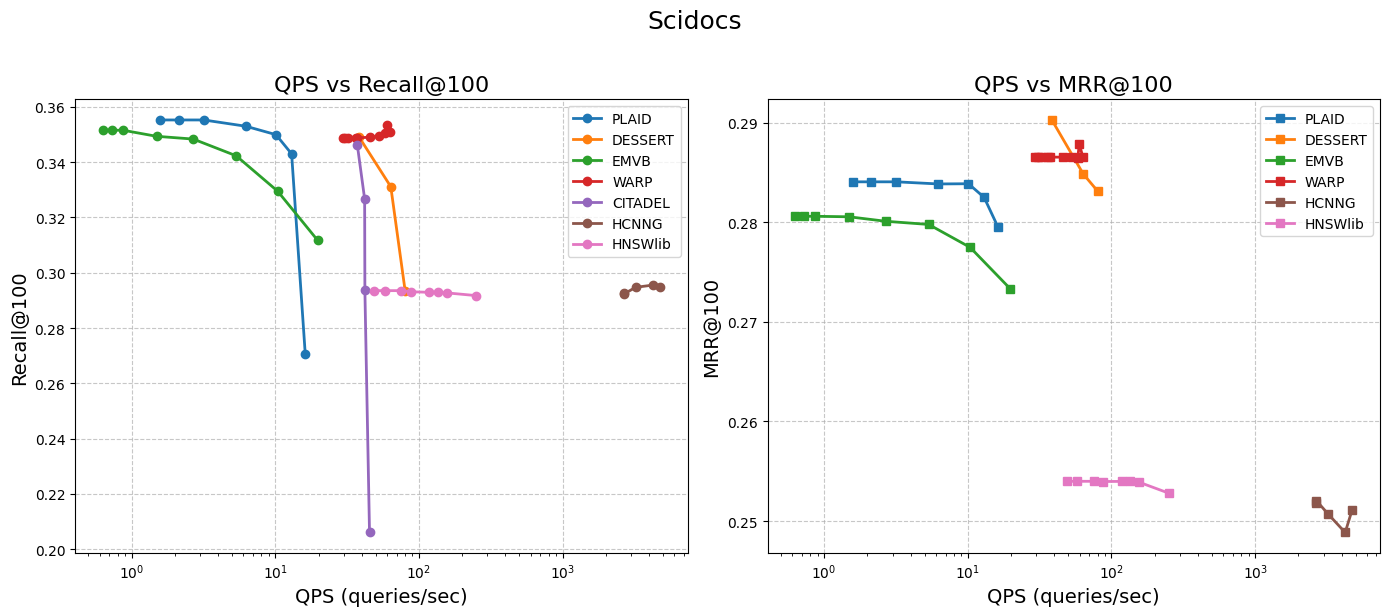

In [9]:
configs = [
    {
        'path': "/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/plaid-scidocs-flat-eval-summary.csv",
        'label': 'PLAID',
        'topk': 100,
        'filters': {'retrieval_ndocs': [200,500,1000,2000,5000,8000,10000]}
    },
    {
        'path': "/data1/chenyifeng/Dataset/multi-vector-retrieval/Result/performance/dessert-scidocs-flat-eval-summary.csv",
        'label': 'DESSERT',
        'topk': 100,
        'filters': {
                        'retrieval_nprobe_query': [4],                      
                        'retrieval_initial_filter_k': [100, 200, 500]
                    }
    },
    {
        'path': '/data1/chenyifeng/MultiVector-Backup/EMVB/work/results/scidocs_colbert_simple/emvb_ivfpq_l2_nlist4096_m32/metrics_summary.csv',
        'label': 'EMVB',
        'topk': 100,
        'filters': {'search_ratio': [0.25, 0.5, 1, 2, 4, 8, 16, 32]}
    },
    {
        'path': '/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.45_ndocs1024.csv',
        'label': 'WARP',
        'topk': None,
        'filters': {'ncells': [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]}
    },
    {
        'path': '/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv',
        'label': 'CITADEL',
        'topk': None,
        'filters': {'pruning_weight': [0.7, 1.3, 1.5, 1.7]}
    },
    {
        'path': "/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hcnng/summary.csv",
        'label': 'HCNNG',
        'topk': 100,
        'filters': {'max_calc': [1000, 2000, 3000, 4000, 5000]}
    },
    {
        'path': "/data1/chenyifeng/MultiVector-Backup/svr-baselines/runs/scidocs-single/hnswlib/summary.csv",
        'label': 'HNSWlib',
        'topk': 100,
        'filters': {'ef_search': [500, 800, 1000, 1200, 2000, 3000, 4000, 5000]}
    }
]

plot_all_methods(
        configs,
        suptitle='Scidocs',
        output_path='./scidocs_qps_metrics.png'
    )